# 🧰 Import Toolkit

In [203]:
import ds_tool_kit as dk
from ds_tool_kit import *

# 📂 Load Data

In [204]:
df = pd.read_csv("/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv",sep="\t")

# 🔍 EDA

In [205]:
statistical_analysis(df)

## 📊 1. General Overview

,Value
Rows,2240
Columns,29
Duplicates,0
Total Missing Values,24


## 🧾 2. Data Types & Missing Values

,Type,Null Count,Null %
Income,float64,24,1.07%
ID,int64,0,0.00%
Year_Birth,int64,0,0.00%
Education,object,0,0.00%
Marital_Status,object,0,0.00%
Kidhome,int64,0,0.00%
Teenhome,int64,0,0.00%
Dt_Customer,object,0,0.00%
Recency,int64,0,0.00%
MntWines,int64,0,0.00%


## 📈 3. Numerical Statistics

...

,Count
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


### 🔹 Marital_Status  *(Unique values: 8)*

,Count
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


### 🔹 Dt_Customer  *(Unique values: 663)*

⚠️ Skipped — High cardinality (663 unique values)

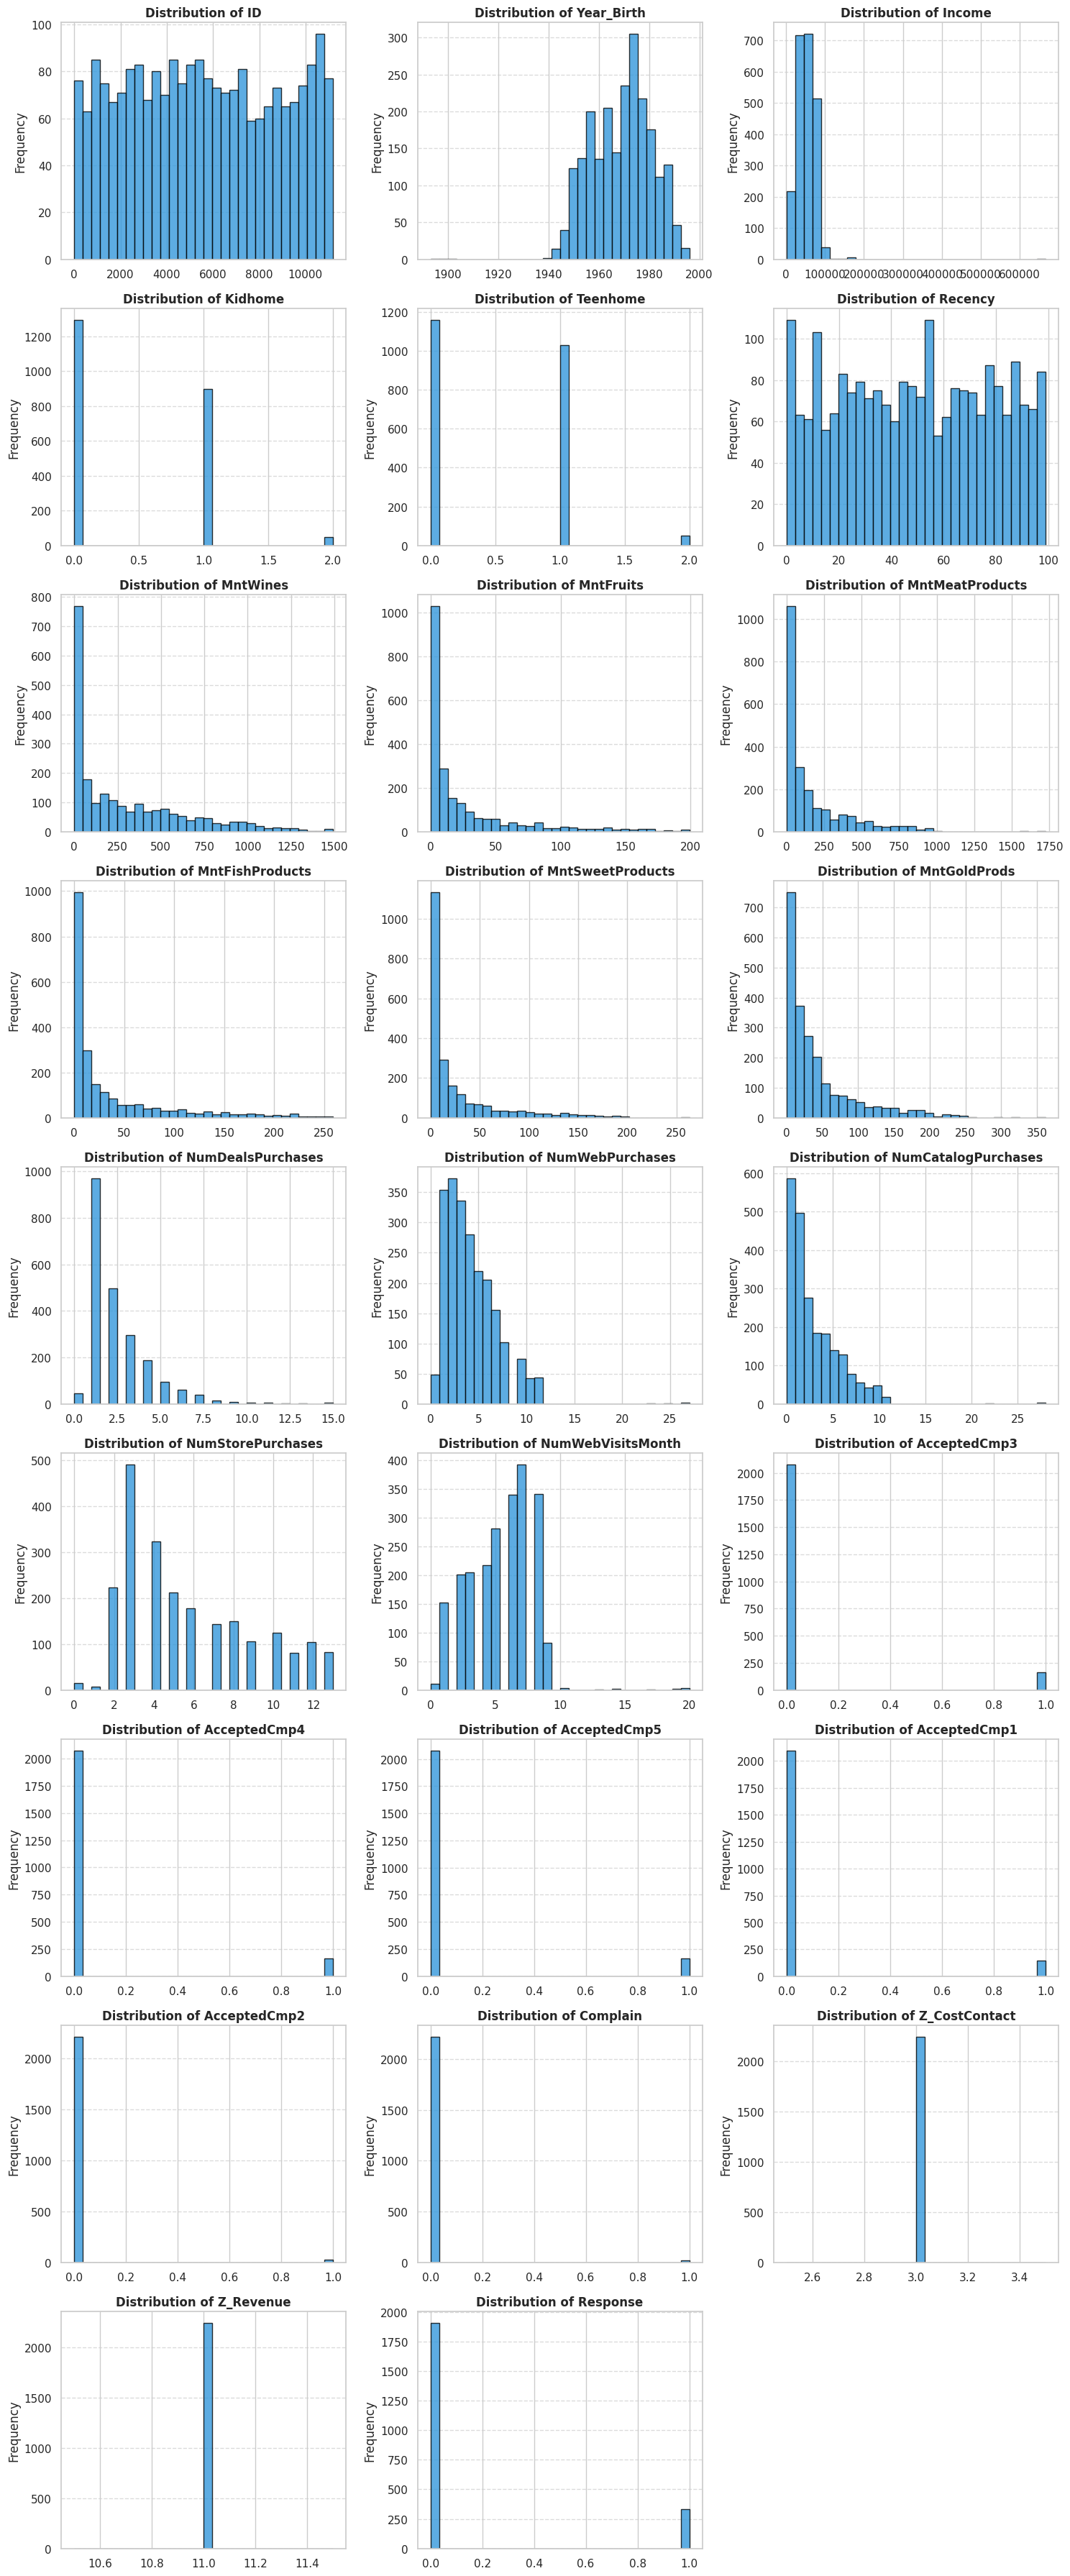

In [206]:
plot_distributions(df)

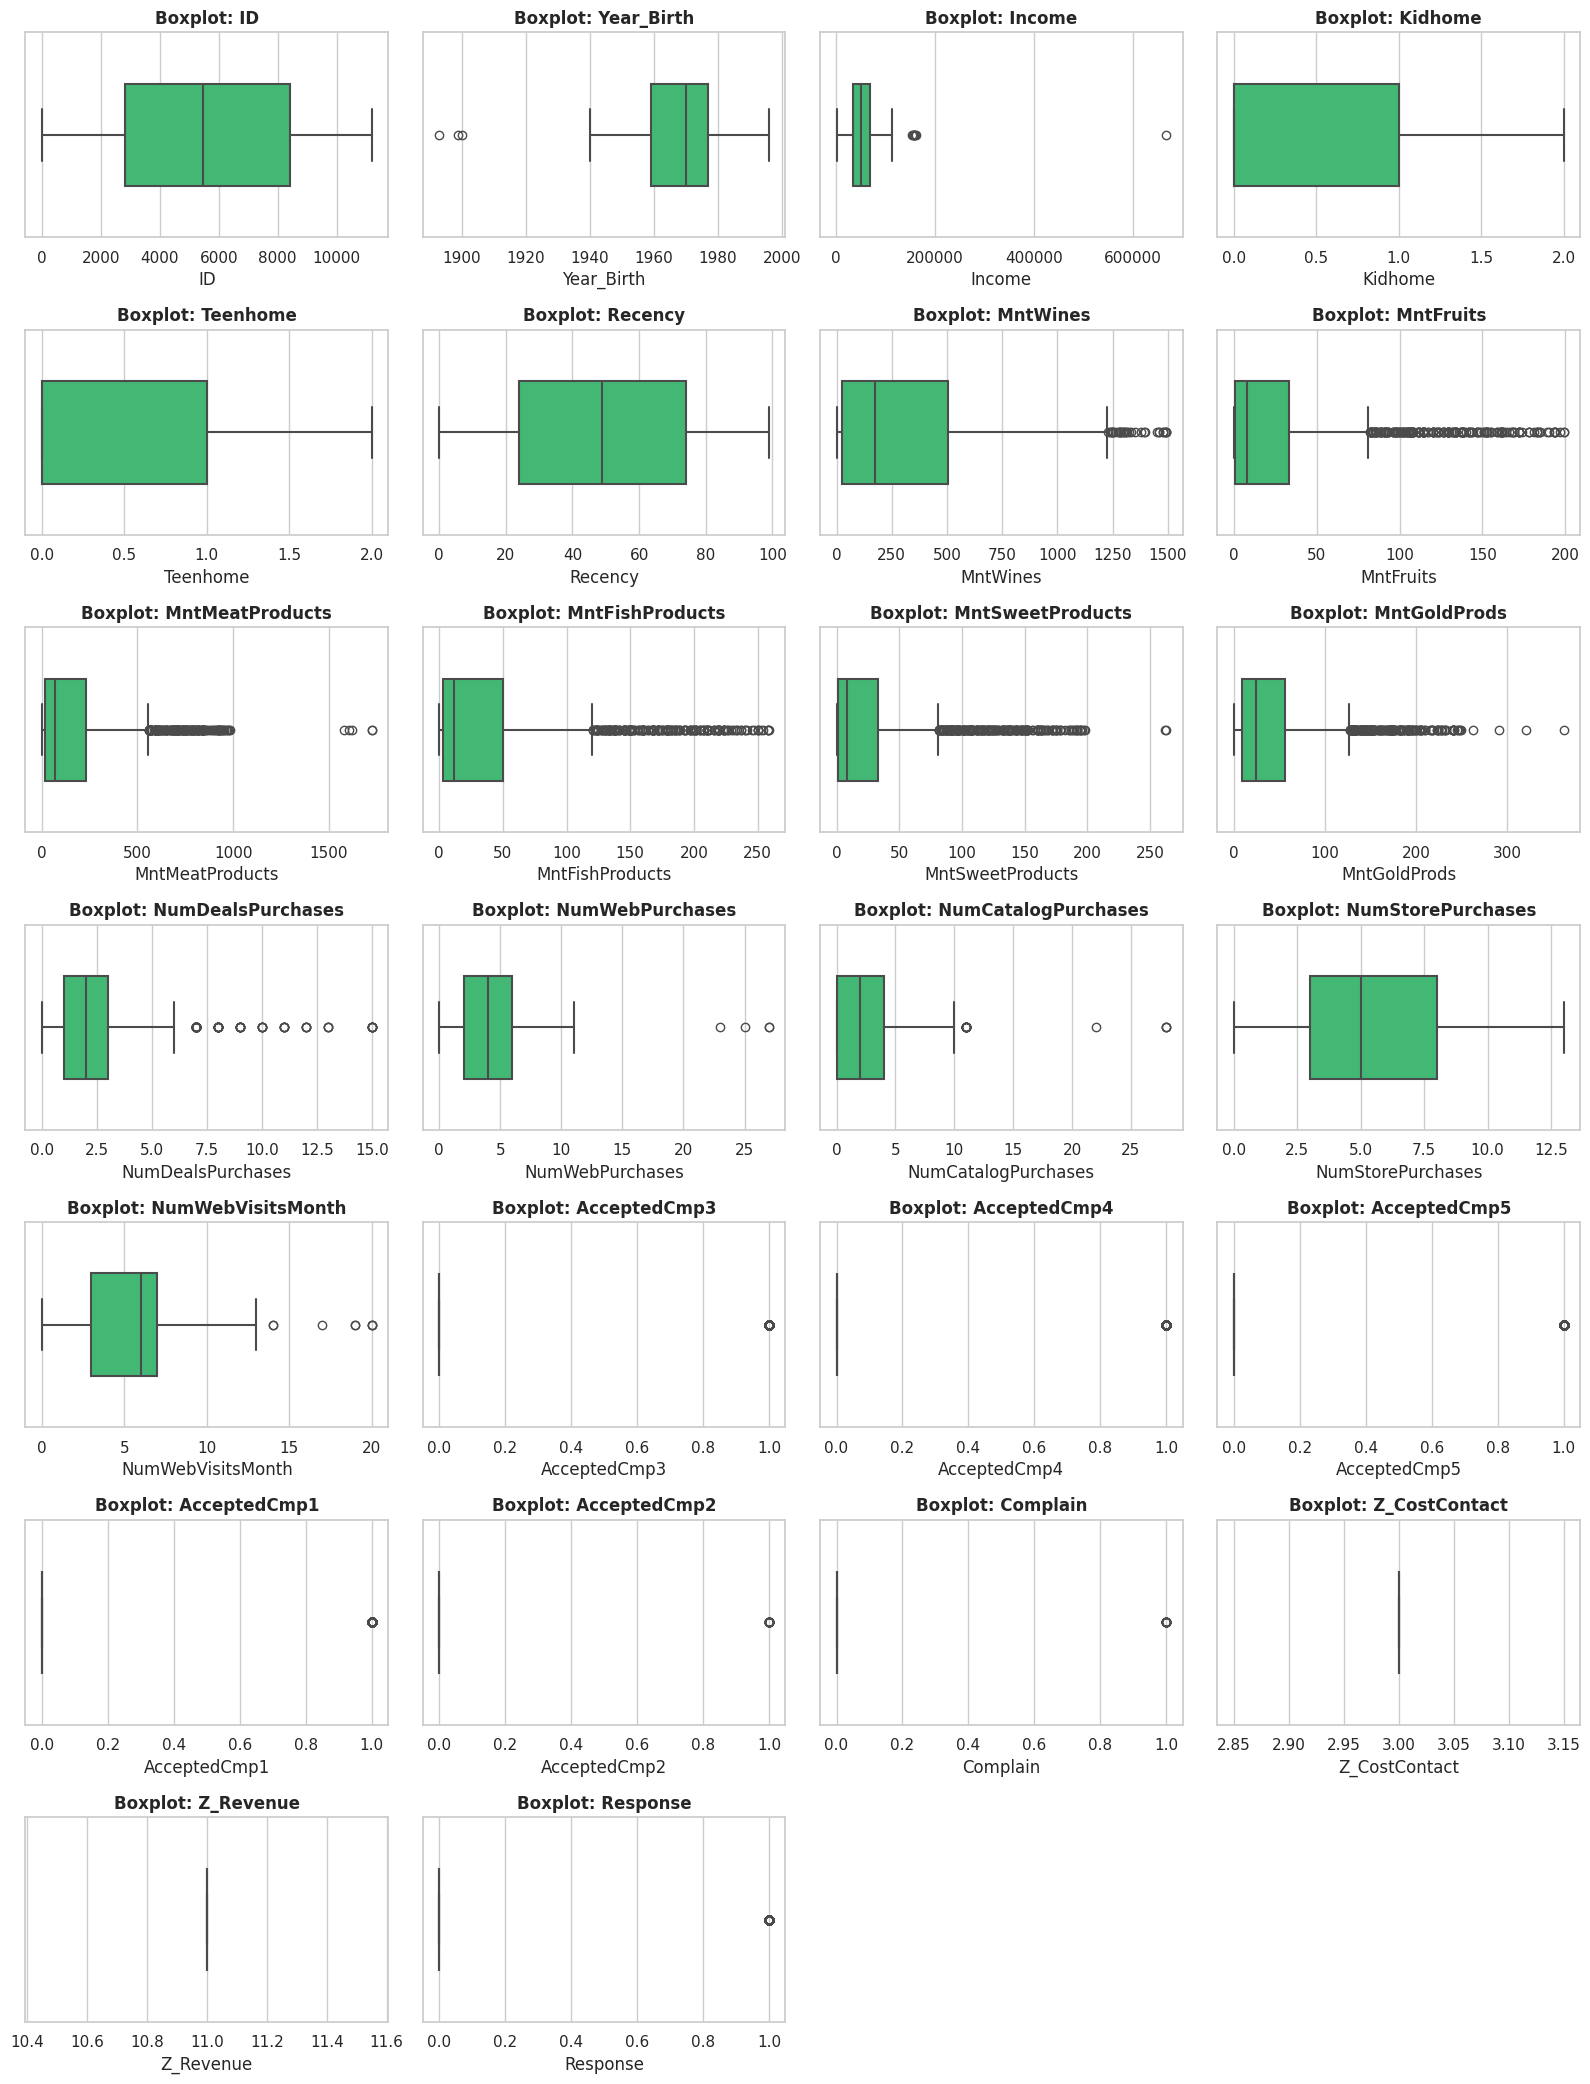

In [207]:
plot_outliers(df)

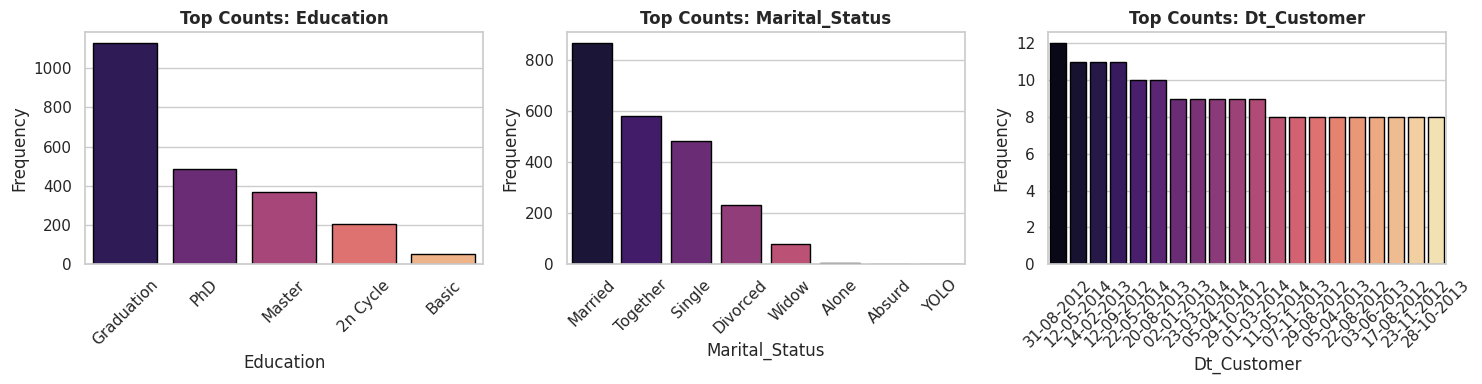

In [208]:
plot_categoricals(df)

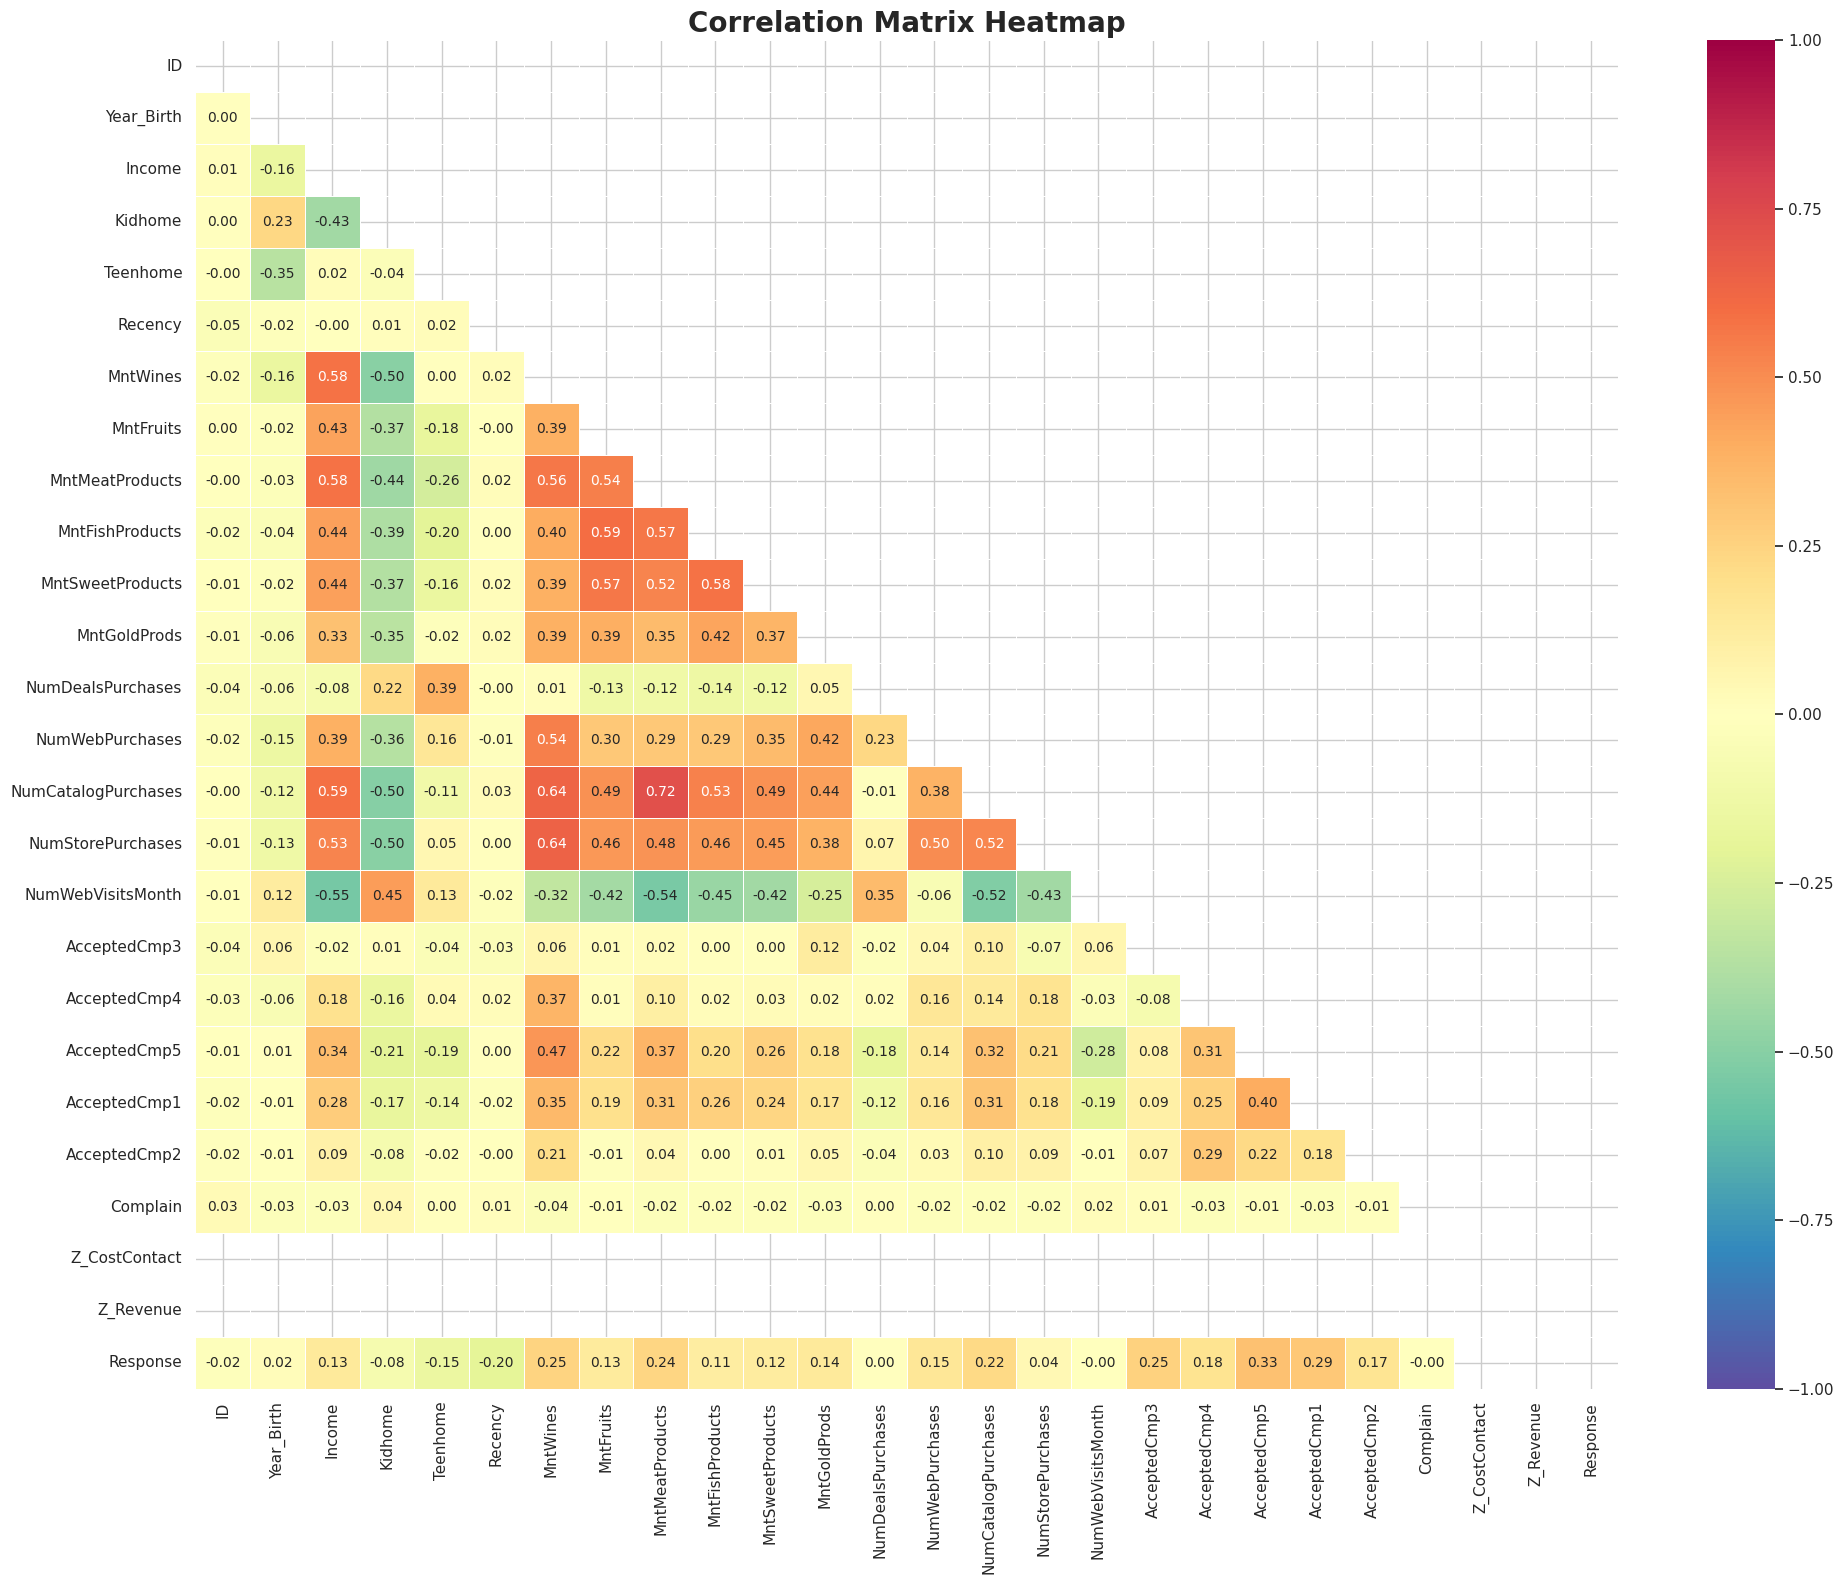

In [209]:
plot_correlation(df)

# ⚖️ Data Standardization

In [210]:
df['Marital_Status'] = df['Marital_Status'].replace({'YOLO': 'Single', 'Absurd': 'Single', 'Alone': 'Single'})
df['Education'] = df['Education'].replace({'2n Cycle': 'Master'})

# ❓ Handling Missing Values

In [211]:
df['Income'].fillna(df['Income'].median(), inplace=True)     

# 🚨 Handling Outliers

In [212]:
df = df[
    (df["Year_Birth"] >= 1940) &
    (df["Year_Birth"] <= 2000)
]

income_cap = df['Income'].quantile(0.99)
df['Income'] = np.where(df['Income'] > income_cap, income_cap, df['Income'])

# 👯 Handling Duplicates

In [213]:
df.duplicated().sum()

np.int64(0)

# ⚙️ Feature Engineering

In [214]:
df["Web_Purchase_To_Visit_Ratio"] = df["NumWebPurchases"] / (df["NumWebVisitsMonth"] + 1) 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
max_date = df["Dt_Customer"].max()
df["Customer_Tenure"] = (max_date - df["Dt_Customer"]).dt.days

In [215]:
df["Total_Spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df["Total_Purchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"] + df["NumDealsPurchases"]

df["Wine_Share"] = df["MntWines"] / (df["Total_Spent"] + 1e-5)
df["Fruit_Share"] = df["MntFruits"] / (df["Total_Spent"] + 1e-5)
df["Meat_Share"] = df["MntMeatProducts"] / (df["Total_Spent"] + 1e-5)
df["Fish_Share"] = df["MntFishProducts"] / (df["Total_Spent"] + 1e-5)
df["Sweet_Share"] = df["MntSweetProducts"] / (df["Total_Spent"] + 1e-5)
df["Gold_Share"] = df["MntGoldProds"] / (df["Total_Spent"] + 1e-5)

In [216]:
df["Parents"] = np.where(df["Marital_Status"].isin(["Married", "Together"]), 2, 1)
df["Family_Size"] = df["Teenhome"] + df["Kidhome"] + df["Parents"]
df["isParent"] = np.where((df["Kidhome"] + df["Teenhome"]) > 0, 1, 0)
df["Age"] = (
    max_date - pd.to_datetime(
        df["Year_Birth"].astype(str) + "-01-01"
    )
).dt.days / 365.25

In [217]:
df["Total_Promos_Accepted"] = df["AcceptedCmp1"] + df["AcceptedCmp2"] + df["AcceptedCmp3"] + df["AcceptedCmp4"] + df["AcceptedCmp5"] + df["Response"]

In [218]:
df["Total_Spent"] = np.log1p(df["Total_Spent"])

# 🗑️ Drop Features

In [219]:
features_to_drop = [
    "ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Kidhome","Teenhome", 
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response","Parents",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases","NumWebVisitsMonth"
]
df_clustering = df.drop(columns=features_to_drop)

# 📊 2nd EDA

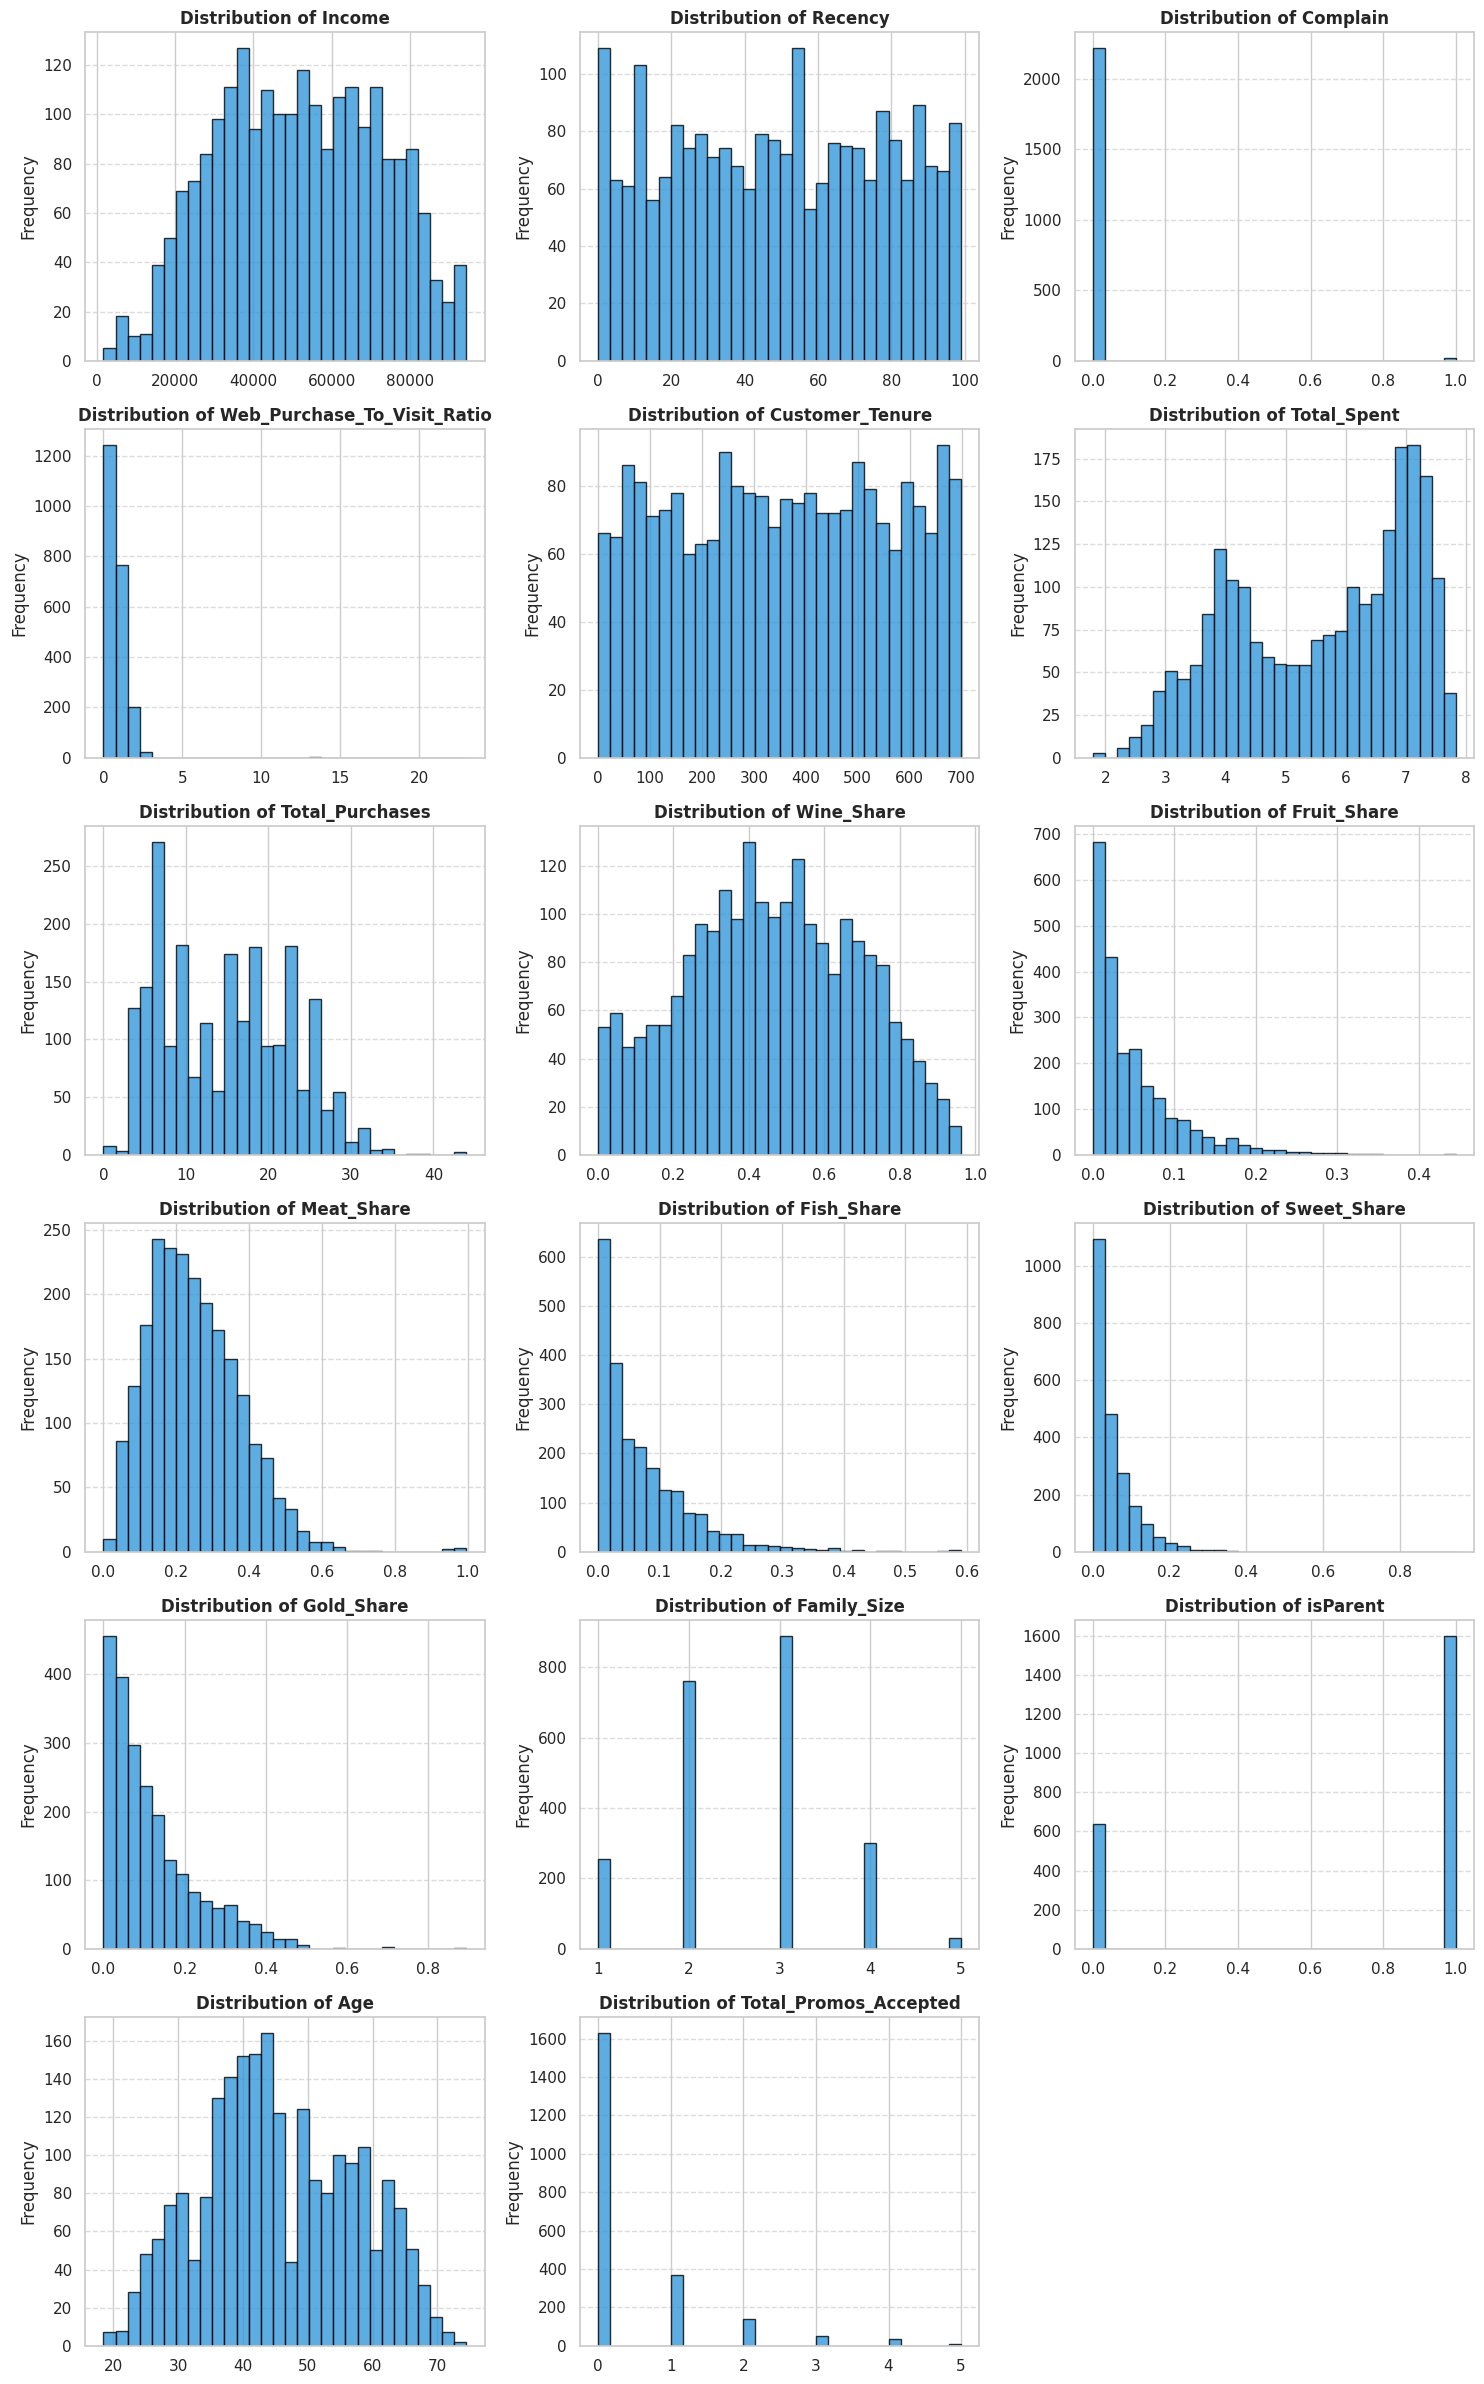

In [220]:
plot_distributions(df_clustering)

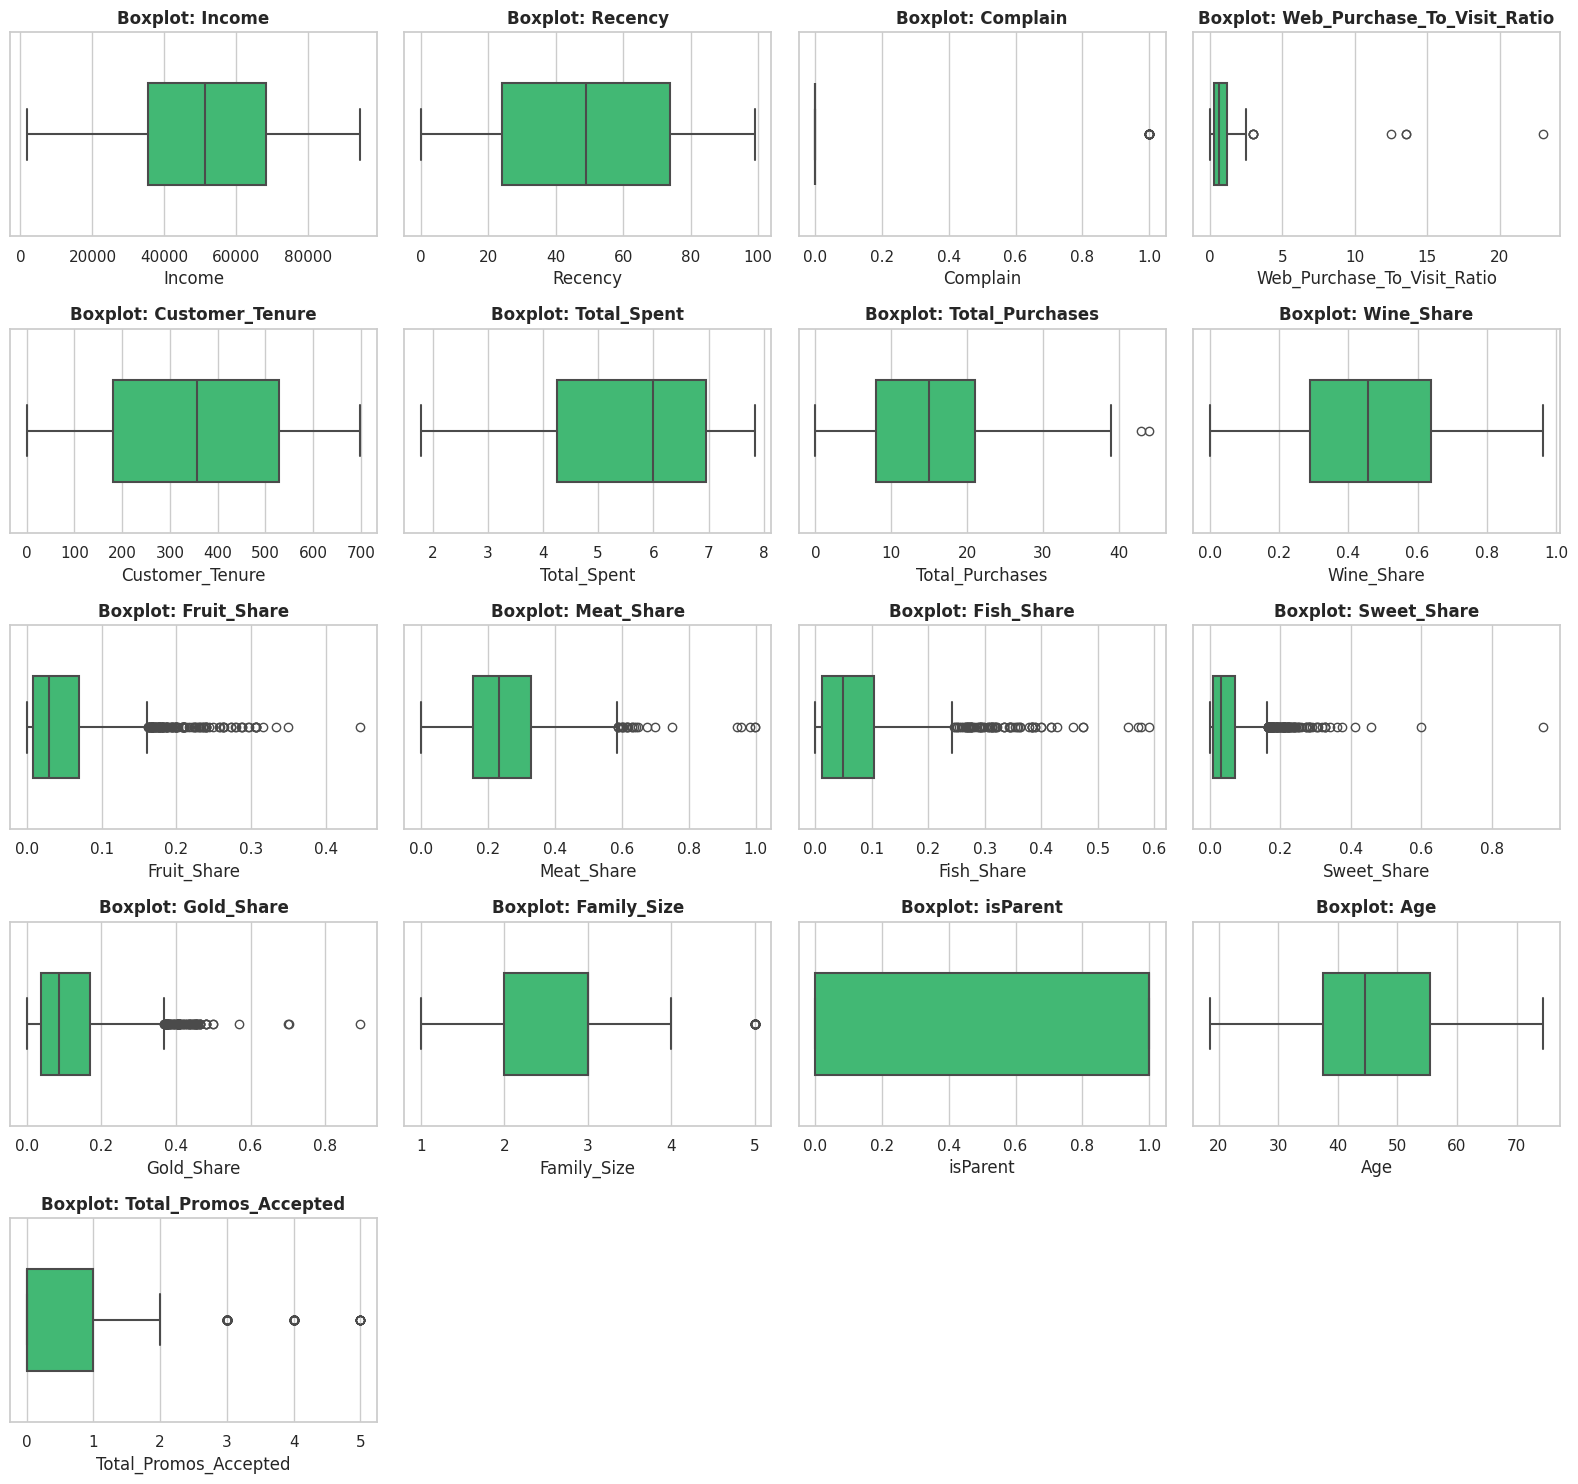

In [221]:
plot_outliers(df_clustering)

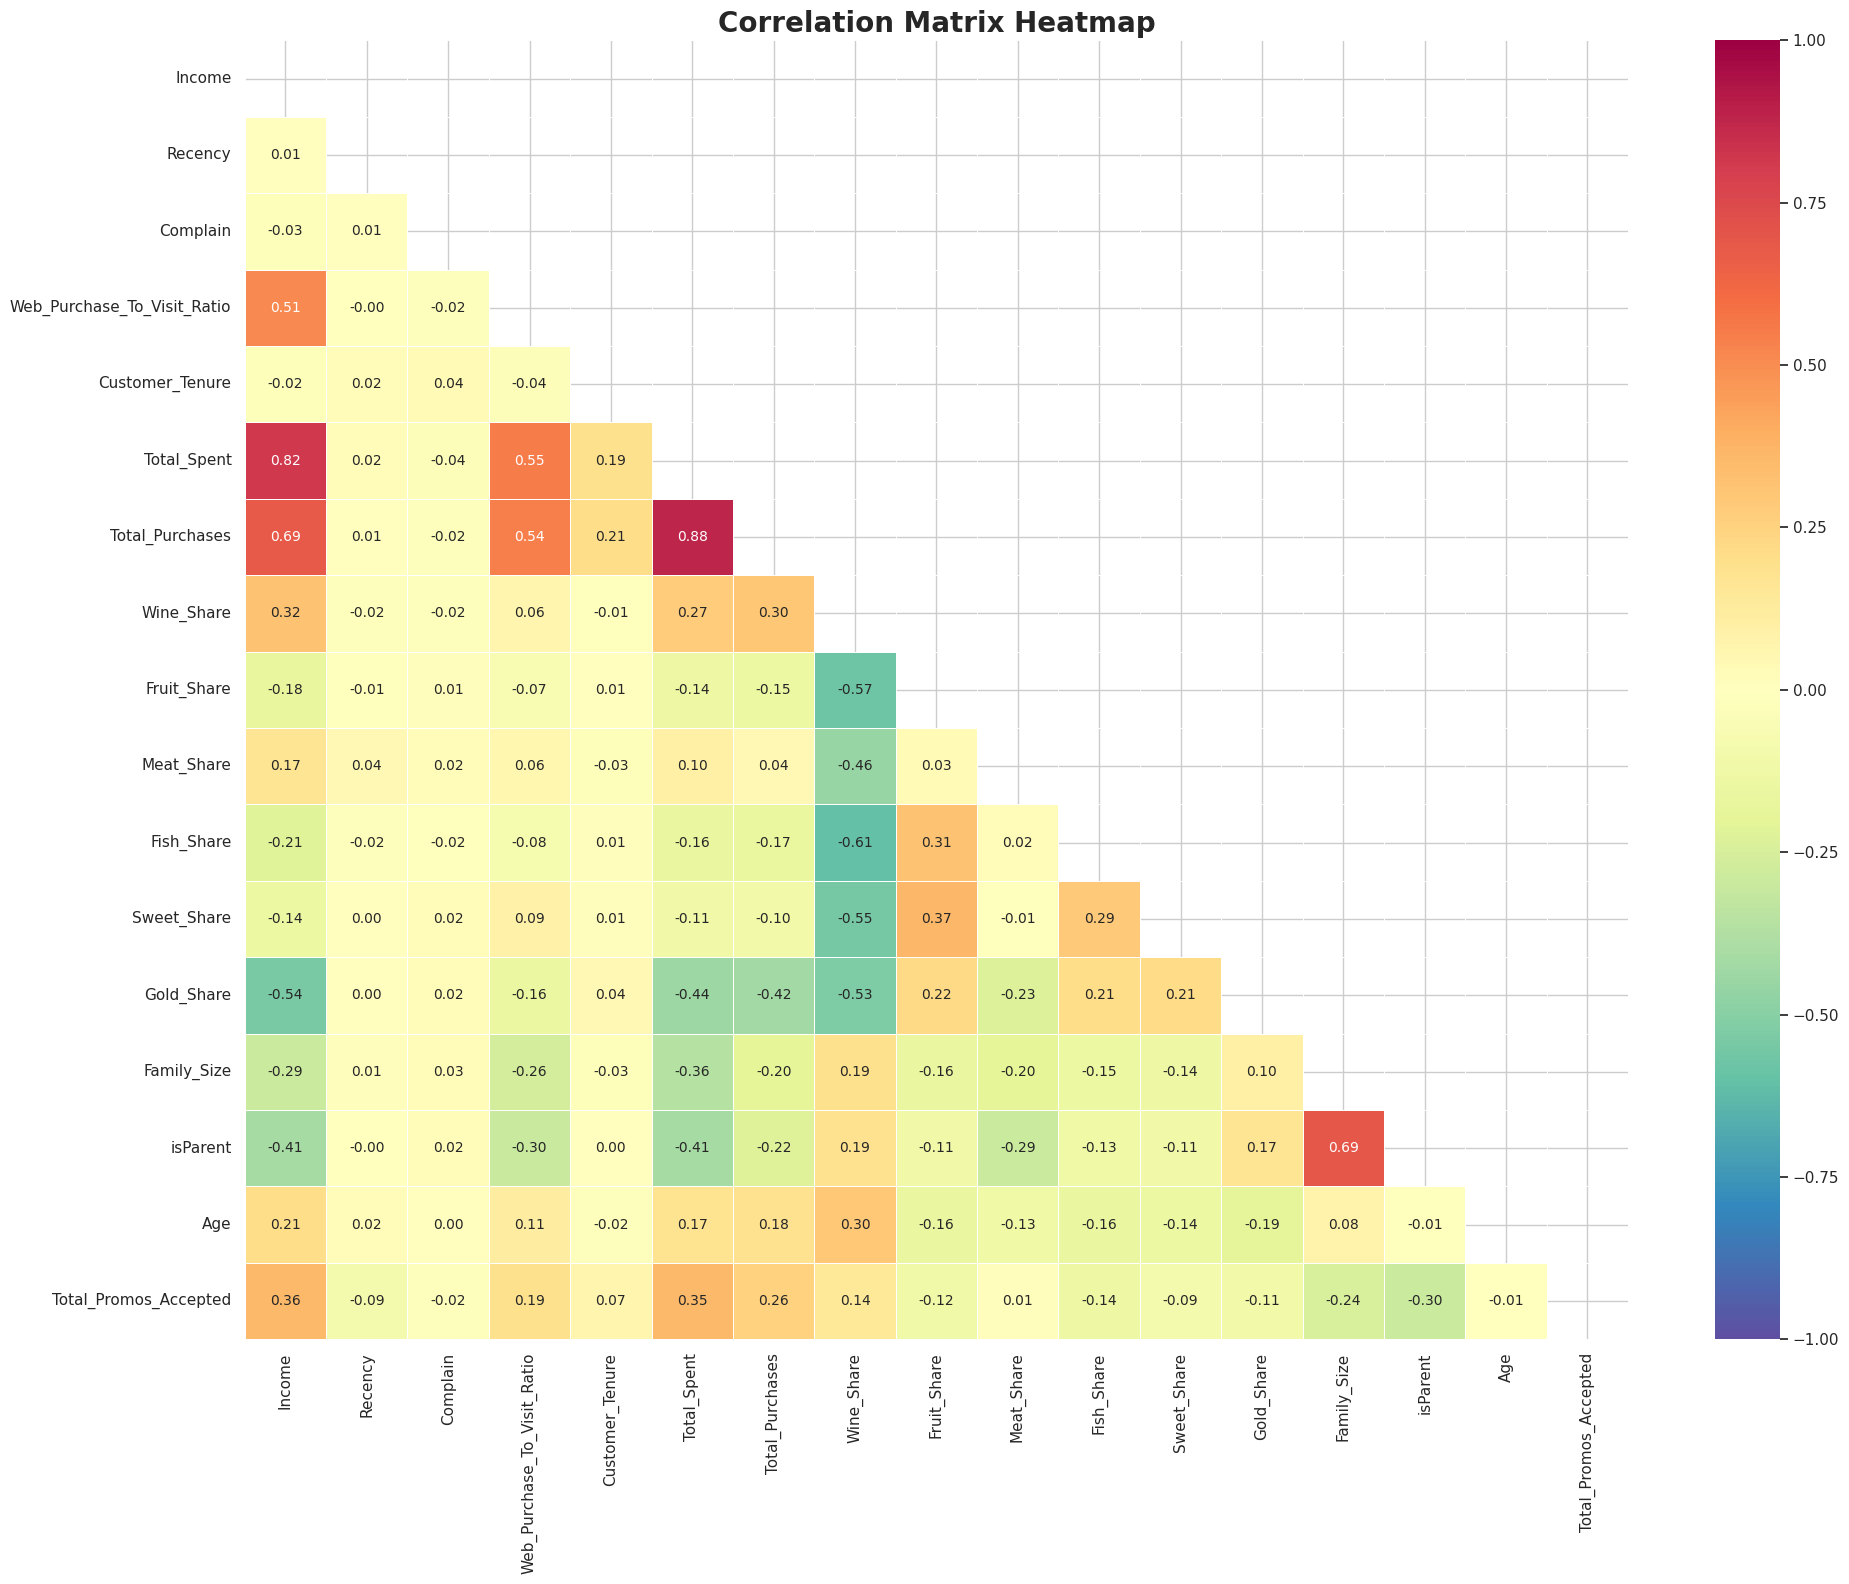

In [222]:
plot_correlation(df_clustering)

# 🔠 Encoding

In [223]:
df_clustering = pd.get_dummies(df_clustering, columns=['Education', 'Marital_Status'], drop_first=True)

# 📏 Scaling

In [224]:
scaler = StandardScaler() 
df_scaled = scaler.fit_transform(df_clustering) 

# 🕶️ Dimensionality Reduction

In [225]:
pca = PCA(n_components=2, random_state=42) 
df_pca = pca.fit_transform(df_scaled) 

# 🧠 Model 

In [226]:
kmeans_3 = KMeans(n_clusters=3, init='random', n_init=10, max_iter=100, random_state=42)
labels_3 = kmeans_3.fit_predict(df_pca)
df_clustering["Cluster"] = labels_3

In [227]:
df_clustering["Real_Total_Spent"] = np.expm1(df_clustering["Total_Spent"])

agg_dict = {
    "Age": "mean",
    "Income": "median",
    "Family_Size": "mean",
    "Real_Total_Spent": "mean",
    "Total_Purchases": "mean",
    "Wine_Share": "mean",
    "Meat_Share": "mean",
    "Gold_Share": "mean",
    "Total_Promos_Accepted": "mean",
    "isParent": "mean", 
    "Web_Purchase_To_Visit_Ratio": "mean"
}

cat_cols = [c for c in df_clustering.columns if "Education" in c or "Marital_Status" in c]
for col in cat_cols:
    agg_dict[col] = "mean"

valid_agg_dict = {k: v for k, v in agg_dict.items() if k in df_clustering.columns}

final_profiles = df_clustering.groupby("Cluster").agg(valid_agg_dict).round(2)
sil_score = silhouette_score(df_pca, labels_3)
dbi_score = davies_bouldin_score(df_pca, labels_3)

# ✅ Model Evaluation

In [228]:
print("K-Means Evaluation Metrics:")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index (DBI): {dbi_score:.4f}\n")

K-Means Evaluation Metrics:
Silhouette Score: 0.4309
Davies-Bouldin Index (DBI): 0.7986



# 💼 Marketing Personas
| Cluster | Name                                    | Core identity                                                            |
| ------- | --------------------------------------- | ------------------------------------------------------------------------ |
| **0**   | **Established Wine-Focused Families**   | Older, family-heavy, moderate spenders with strong wine preference       |
| **1**   | **Low-Value, Low-Engagement Customers** | Lowest income/spend/purchases and weak campaign response                 |
| **2**   | **High-Value, High-Intent Customers**   | Highest income/spend/purchases and strongest digital/campaign engagement |


In [229]:
print("K-Means Cluster Sizes:")
print(pd.Series(labels_3).value_counts().sort_index())

print("\n--- k=3 Marketing Personas ---")
print(final_profiles.T)

K-Means Cluster Sizes:
0    865
1    642
2    730
Name: count, dtype: int64

--- k=3 Marketing Personas ---
Cluster                              0          1          2
Age                            49.0100    39.7700    46.6500
Income                      50200.0000 29878.5000 73263.0000
Family_Size                     3.1500     2.6600     1.8800
Real_Total_Spent              425.2700   104.1400  1260.7300
Total_Purchases                14.9700     7.7800    20.9900
Wine_Share                      0.6500     0.2300     0.4400
Meat_Share                      0.1900     0.2600     0.3100
Gold_Share                      0.0900     0.2200     0.0700
Total_Promos_Accepted           0.2800     0.1700     0.8900
isParent                        0.9900     0.8200     0.3000
Web_Purchase_To_Visit_Ratio     0.6400     0.2900     1.4500
Education_Graduation            0.3600     0.6000     0.5800
Education_Master                0.2700     0.2800     0.2200
Education_PhD                   0.3700

# 🗺️ Model Visualization

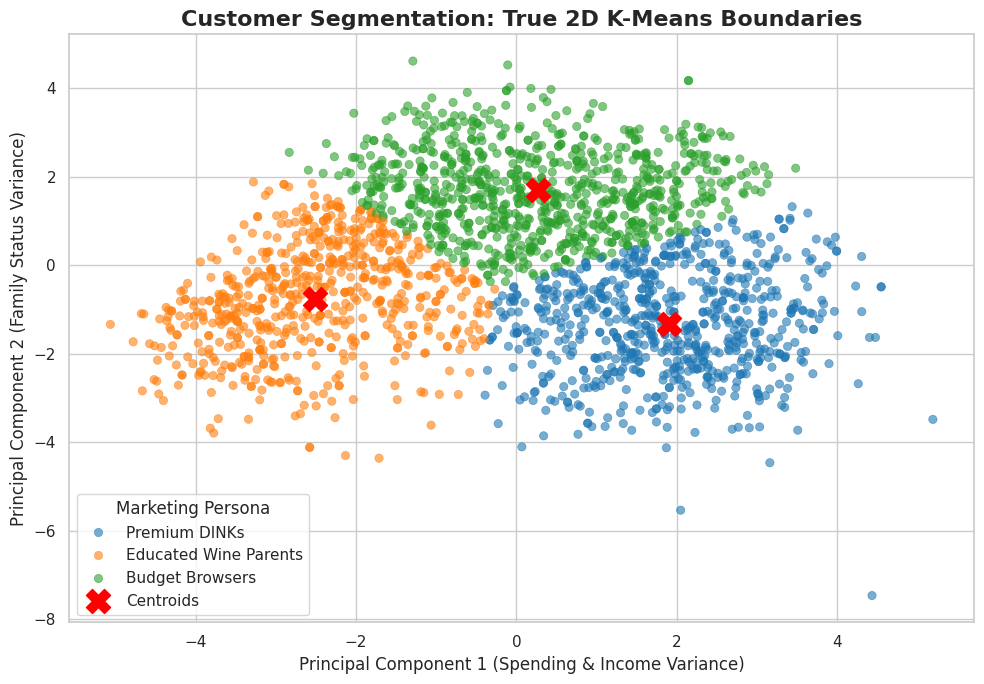

In [230]:
df_pca_plot = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca_plot['Cluster'] = labels_3

persona_map = {
    0: "Budget Browsers", 
    1: "Educated Wine Parents", 
    2: "Premium DINKs"
}
df_pca_plot['Persona'] = df_pca_plot['Cluster'].map(persona_map)

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Persona', 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'], 
    data=df_pca_plot, 
    alpha=0.6, 
    edgecolor=None
)

centroids = kmeans_3.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=300, 
    c='red', 
    marker='X', 
    label='Centroids'
)

plt.title('Customer Segmentation: True 2D K-Means Boundaries', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1 (Spending & Income Variance)', fontsize=12)
plt.ylabel('Principal Component 2 (Family Status Variance)', fontsize=12)
plt.legend(title='Marketing Persona')
plt.tight_layout()
plt.show()

# 💾 Model Saving

In [231]:
joblib.dump(kmeans_3, 'kmeans_customer_segmentation_model.pkl')

joblib.dump(pca, 'pca_customer_segmentation.pkl')

joblib.dump(scaler, 'standard_scaler_segmentation.pkl')

print("💾 Models successfully saved to disk!")

💾 Models successfully saved to disk!
